<a href="https://colab.research.google.com/github/alirezakiann/snappfood-sentiment/blob/main/notebooks/05_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 - Error Analysis & Complaint Clustering
Two very different models (TF-IDF + SVM and BiLSTM) share ~80% of their mistakes. That points to the **data**, not the models.

**Part A - Label audit:** I re-label a random sample of reviews by hand, *without seeing the dataset label*, to estimate how many labels are wrong.

**Part B - What do people complain about?** Cluster the negative reviews to find the main complaint types, and check which foods get the most complaints.

## 0. Setup
GPU is not needed for this notebook.

In [1]:
!pip install -q hazm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.2/887.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
BASE_DIR = "/content/drive/MyDrive/snappfood-sentiment"
PROC_DIR = f"{BASE_DIR}/processed"
MODEL_DIR = f"{BASE_DIR}/models"
AUDIT_PATH = f"{BASE_DIR}/audit_labels.csv"

for p in [f"{PROC_DIR}/test.csv", f"{MODEL_DIR}/baseline_tfidf_model.joblib", f"{MODEL_DIR}/lstm_model.pt"]:
    print(os.path.basename(p), "found:", os.path.exists(p))

Mounted at /content/drive
test.csv found: True
baseline_tfidf_model.joblib found: True
lstm_model.pt found: True


In [3]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from hazm import Normalizer, stopwords_list
from sklearn.metrics import accuracy_score

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", message="This pattern")

In [4]:
# same cleaning function as notebooks 02-04
KEEP = {
    "نه", "نبود", "نیست", "نیستند", "ندارد", "ندارند", "نباید", "نمی‌شود", "هیچ", "بدون", "عدم", "غیر", "بی",
    "اما", "ولی", "بلکه", "حتی", "فقط", "تنها",
    "خیلی", "بسیار", "بسیاری", "کاملا", "کامل", "زیاد", "زیادی", "کم", "کمی", "بیش", "بیشتر", "پر", "کافی",
    "عالی", "خوب", "خوبی", "بهتر", "بهترین", "مناسب", "متاسفانه", "جدی",
    "رسید", "رسیدن", "دیر", "هنوز", "همیشه", "همواره", "دوباره",
}
STOPWORDS = set(stopwords_list()) - KEEP
normalizer = Normalizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
REPEAT_RE = re.compile(r"(.)\1{2,}")
EMOJI_RE = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF]")
PERSIAN = "\u0621-\u063A\u0641-\u064A\u067E\u0686\u0698\u06A9\u06AF\u06CC\u200c"
EMOJI_CHARS = "\U0001F300-\U0001FAFF\U00002600-\U000027BF"
NOT_ALLOWED_RE = re.compile(f"[^{PERSIAN}{EMOJI_CHARS}a-z\\s]")

def clean_text(text, stopwords=STOPWORDS):
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = normalizer.normalize(text)
    text = REPEAT_RE.sub(r"\1", text)
    text = EMOJI_RE.sub(lambda m: f" {m.group(0)} ", text)
    text = NOT_ALLOWED_RE.sub(" ", text)
    tokens = [t.strip("\u200c") for t in text.split()]
    tokens = [t for t in tokens if t and t not in stopwords and (len(t) > 1 or EMOJI_RE.match(t))]
    return " ".join(tokens)

# Part A - How many labels are wrong?

## A1. Predictions of both models on the test set

In [5]:
test = pd.read_csv(f"{PROC_DIR}/test.csv")
test["clean_text"] = test["clean_text"].fillna("")

# model 1: TF-IDF + SVM from notebook 03
baseline = joblib.load(f"{MODEL_DIR}/baseline_tfidf_model.joblib")
test["svm_pred"] = baseline.predict(test["clean_text"])

In [6]:
# model 2: BiLSTM from notebook 04 (same architecture, loaded from Drive)
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x, lengths):
        emb = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        return self.fc(self.dropout(torch.cat([h[-2], h[-1]], dim=1))).squeeze(1)

ckpt = torch.load(f"{MODEL_DIR}/lstm_model.pt", map_location="cpu", weights_only=False)
vocab, max_len, text_col = ckpt["vocab"], ckpt["max_len"], ckpt["text_col"]
lstm = SentimentLSTM(len(vocab))
lstm.load_state_dict(ckpt["state_dict"])
lstm.eval()

def lstm_predict(raw_texts, batch_size=512):
    sw = set() if text_col == "light_text" else STOPWORDS
    preds = []
    for i in range(0, len(raw_texts), batch_size):
        seqs = []
        for t in raw_texts[i:i + batch_size]:
            ids = [vocab.get(tok, 1) for tok in clean_text(t, stopwords=sw).split()][:max_len]
            seqs.append(torch.tensor(ids if ids else [1]))
        lengths = torch.tensor([len(s) for s in seqs])
        with torch.no_grad():
            logits = lstm(pad_sequence(seqs, batch_first=True), lengths)
        preds.extend((torch.sigmoid(logits) >= 0.5).int().tolist())
    return np.array(preds)

test["lstm_pred"] = lstm_predict(test["comment"].tolist())

y = test["sentiment"]
print(f"SVM accuracy:  {accuracy_score(y, test['svm_pred']):.4f}")
print(f"LSTM accuracy: {accuracy_score(y, test['lstm_pred']):.4f}   (should match notebooks 03 and 04)")

SVM accuracy:  0.8641
LSTM accuracy: 0.8598   (should match notebooks 03 and 04)


In [7]:
test["group"] = np.select(
    [(test["svm_pred"] == y) & (test["lstm_pred"] == y),
     (test["svm_pred"] != y) & (test["lstm_pred"] != y)],
    ["both right", "both wrong"], default="models disagree")
test["group"].value_counts()

,count
group,
both right,5752
both wrong,750
models disagree,408


## A2. Build the audit sample
We take **100 reviews both models got wrong** and **50 reviews both got right**, and shuffle them together.

Why include correct ones? Two reasons:
1. If the labeler only sees errors, they may start assuming "the label is always wrong". Mixing hides which is which.
2. It lets us estimate label noise among the "easy" reviews too, not just the hard ones.

The dataset label is **hidden** during labeling (blind labeling), so it can't bias your judgement.

In [8]:
N_WRONG, N_RIGHT = 100, 50

audit = pd.concat([
    test[test["group"] == "both wrong"].sample(N_WRONG, random_state=42),
    test[test["group"] == "both right"].sample(N_RIGHT, random_state=42),
]).sample(frac=1, random_state=7).reset_index().rename(columns={"index": "test_row"})

audit = audit[["test_row", "comment", "label", "group"]]
audit["my_label"] = ""

# resume previous work if a saved file exists
if os.path.exists(AUDIT_PATH):
    saved = pd.read_csv(AUDIT_PATH).fillna("")
    audit = audit.drop(columns="my_label").merge(saved[["test_row", "my_label"]], on="test_row", how="left").fillna("")
    print("Resumed. Already labeled:", (audit["my_label"] != "").sum(), "of", len(audit))
else:
    print("New audit with", len(audit), "reviews")

New audit with 150 reviews


## A3. Label the reviews
For each review, read it and press the button that matches **what the customer actually meant**:
- **Positive** — overall happy
- **Negative** — overall unhappy
- **Mixed / unclear** — really can't tell, or clearly both

Every click is saved to Google Drive right away, so you can stop and continue later by running A2 and A3 again.
It takes about 20-30 minutes for 150 reviews.

In [9]:
import ipywidgets as widgets
from IPython.display import display

# start at the first review that has no answer yet
unlabeled = audit.index[audit["my_label"] == ""]
state = {"i": int(unlabeled[0]) if len(unlabeled) else len(audit)}

text_box = widgets.HTML()
progress = widgets.HTML()
btn_pos = widgets.Button(description="Positive", button_style="success", layout=widgets.Layout(width="150px"))
btn_neg = widgets.Button(description="Negative", button_style="danger", layout=widgets.Layout(width="150px"))
btn_mix = widgets.Button(description="Mixed / unclear", button_style="warning", layout=widgets.Layout(width="150px"))
btn_back = widgets.Button(description="Back", layout=widgets.Layout(width="100px"))

def show():
    i = state["i"]
    done = (audit["my_label"] != "").sum()
    progress.value = f"<b>{done} / {len(audit)} labeled</b>"
    if i >= len(audit):
        text_box.value = "<h3>All done! Run the next cell.</h3>"
        return
    current = audit.loc[i, "my_label"]
    note = f"<br><i>(current answer: {current})</i>" if current else ""
    text_box.value = (f"<div dir='rtl' style='font-size:20px; line-height:1.8; padding:14px; "
                      f"border:1px solid #999; border-radius:8px; max-width:750px'>{audit.loc[i, 'comment']}</div>"
                      f"<p>review {i + 1} of {len(audit)}{note}</p>")

def answer(value):
    def handler(_):
        if state["i"] >= len(audit):
            return
        audit.loc[state["i"], "my_label"] = value
        audit.to_csv(AUDIT_PATH, index=False)
        state["i"] += 1
        show()
    return handler

def go_back(_):
    state["i"] = max(0, state["i"] - 1)
    show()

btn_pos.on_click(answer("HAPPY"))
btn_neg.on_click(answer("SAD"))
btn_mix.on_click(answer("MIXED"))
btn_back.on_click(go_back)

show()
display(widgets.VBox([progress, text_box, widgets.HBox([btn_pos, btn_neg, btn_mix, btn_back])]))

## A4. Results of the audit

In [10]:
done = audit[audit["my_label"] != ""].copy()
print(f"Labeled: {len(done)} of {len(audit)}\n")

def verdict(row):
    if row["my_label"] == "MIXED":
        return "mixed / unclear"
    return "dataset label correct" if row["my_label"] == row["label"] else "dataset label WRONG"

done["verdict"] = done.apply(verdict, axis=1)
table = pd.crosstab(done["group"], done["verdict"], normalize="index").mul(100).round(1)
table["n"] = done["group"].value_counts()
table

Labeled: 150 of 150



verdict,dataset label WRONG,dataset label correct,mixed / unclear,n
group,,,,
both right,6.0,92.0,2.0,50
both wrong,71.0,22.0,7.0,100


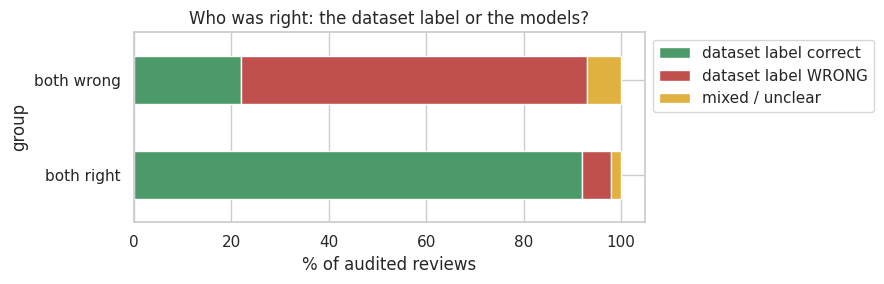

In [11]:
order = ["dataset label correct", "dataset label WRONG", "mixed / unclear"]
colors = {"dataset label correct": "#4C9A6A", "dataset label WRONG": "#C0504D", "mixed / unclear": "#E0B040"}
shares = pd.crosstab(done["group"], done["verdict"], normalize="index").mul(100)
shares = shares[[c for c in order if c in shares.columns]]
ax = shares.plot(kind="barh", stacked=True, figsize=(9, 3), color=[colors[c] for c in shares.columns])
ax.set_xlabel("% of audited reviews")
ax.set_title("Who was right: the dataset label or the models?")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### What does this mean for accuracy?
A rough estimate: among the reviews **both models got wrong**, the ones with a wrong dataset label are not really model mistakes.
If we count them as correct (and count wrong labels among "both right" reviews as real mistakes), we get an estimated accuracy on *true* labels.
This is an estimate from a small sample, not an exact number.

In [12]:
counts = test["group"].value_counts()
rates = done.groupby("group")["verdict"].value_counts(normalize=True).unstack().fillna(0)

wrong_rate_in_errors = rates.loc["both wrong"].get("dataset label WRONG", 0)
wrong_rate_in_right = rates.loc["both right"].get("dataset label WRONG", 0) if "both right" in rates.index else 0

svm_acc = accuracy_score(y, test["svm_pred"])
fake_errors = wrong_rate_in_errors * counts["both wrong"]
hidden_errors = wrong_rate_in_right * counts["both right"]
adj_acc = svm_acc + (fake_errors - hidden_errors) / len(test)

print(f"Among shared errors, dataset label wrong:  {wrong_rate_in_errors:.0%}  (~{fake_errors:.0f} of {counts['both wrong']} reviews)")
print(f"Among shared correct, dataset label wrong: {wrong_rate_in_right:.0%}  (~{hidden_errors:.0f} of {counts['both right']} reviews)")
print(f"\nSVM accuracy on dataset labels:      {svm_acc:.1%}")
print(f"Estimated SVM accuracy on true labels: {adj_acc:.1%}")

Among shared errors, dataset label wrong:  71%  (~532 of 750 reviews)
Among shared correct, dataset label wrong: 6%  (~345 of 5752 reviews)

SVM accuracy on dataset labels:      86.4%
Estimated SVM accuracy on true labels: 89.1%


In [13]:
# examples of each verdict among the shared errors
for v in ["dataset label WRONG", "dataset label correct", "mixed / unclear"]:
    ex = done[(done["group"] == "both wrong") & (done["verdict"] == v)]
    print(f"\n=== {v} ({len(ex)}) ===")
    for _, r in ex.head(4).iterrows():
        print(f"[dataset: {r['label']:5} | me: {r['my_label']:5}]  {r['comment'][:160]}")


=== dataset label WRONG (71) ===
[dataset: HAPPY | me: SAD  ]  سیب زمینی‌ها غرق در روغن، مونده و سیاه بودن
[dataset: HAPPY | me: SAD  ]  نان ترد نبود اصلا، کیفیت مناسبی نداشت داخل منو همراه سفارش سس تکنفره بود که با غذا ارسال نشد
[dataset: HAPPY | me: SAD  ]  کوچیک بود ۲ نفره سفارش بدین
[dataset: HAPPY | me: SAD  ]  پیک سفارش رو اشتباه تحویل نفر دیگه داده بود

=== dataset label correct (22) ===
[dataset: HAPPY | me: HAPPY]  چند ساله مشتری باگتم و تا حالا نشده از سفارشم ناراضی باشم انواع سالاد، ساندویچ، برگر، پیتزا، دیپ دیش و پیش غذا رو تست کردم مواد اولیه‌ی مرغوب، طراحی چشم‌نواز و 
[dataset: HAPPY | me: HAPPY]  در اسرع وقت ارسال شد.
[dataset: SAD   | me: SAD  ]  رکود تاخیرو با ١٦٠ دقیقه تاخیر زدید خسته نباشید خدا قوت
[dataset: SAD   | me: SAD  ]  بهتره که سس سالاد جدا باشه چون هم باعث میشه کاهو‌ها نرم بشن هم اینکه شاید اون میزان سس واسه ذائقه‌ی یک نفر زیاد باشه. قارچ سوخاری رو توی ظرف مقوایی بسته بندی کن

=== mixed / unclear (7) ===
[dataset: SAD   | me: MIXED]  جوجه کمی سوخته بود و ک

# Part B - What do people complain about?

## B1. Which foods get the most complaints?
In notebook 01, «پیتزا» appeared only in the SAD word list. Is pizza really worse, or just ordered more?
We compare the **complaint rate** (share of negative reviews) for reviews mentioning each food.

In [14]:
full = pd.concat([pd.read_csv(f"{PROC_DIR}/{n}.csv") for n in ["train", "val", "test"]], ignore_index=True)
full["clean_text"] = full["clean_text"].fillna("")
print(f"{len(full):,} reviews | overall complaint rate: {(full['sentiment'] == 0).mean():.1%}")

FOODS = {
    "پیتزا": r"پیتزا", "برگر": r"برگر", "ساندویچ": r"ساندویچ", "کباب": r"کباب", "جوجه": r"جوجه",
    "مرغ / سوخاری": r"مرغ|سوخاری", "پاستا / ماکارونی": r"پاستا|ماکارونی", "سالاد": r"سالاد",
    "سوشی": r"سوشی", "کیک / شیرینی": r"کیک|شیرینی", "قهوه / نوشیدنی": r"قهوه|نوشیدنی|نوشابه",
    "سیب زمینی": r"سیب ?زمینی", "برنج / چلو": r"برنج|چلو",
}
rows = []
for food, pat in FOODS.items():
    m = full["comment"].str.contains(pat, regex=True)
    if m.sum() >= 100:
        rows.append({"food": food, "reviews": int(m.sum()), "complaint_rate": (full.loc[m, "sentiment"] == 0).mean()})
foods = pd.DataFrame(rows).sort_values("complaint_rate", ascending=False).reset_index(drop=True)
foods["complaint_rate"] = foods["complaint_rate"].round(3)
foods

69,100 reviews | overall complaint rate: 50.3%


,food,reviews,complaint_rate
0,مرغ / سوخاری,5499,0.658
1,قهوه / نوشیدنی,1353,0.643
2,برنج / چلو,2046,0.630
3,کیک / شیرینی,4381,0.610
4,سیب زمینی,3022,0.607
5,پیتزا,7648,0.606
6,کباب,2260,0.604
7,پاستا / ماکارونی,504,0.599
8,برگر,2057,0.599
9,جوجه,1752,0.592


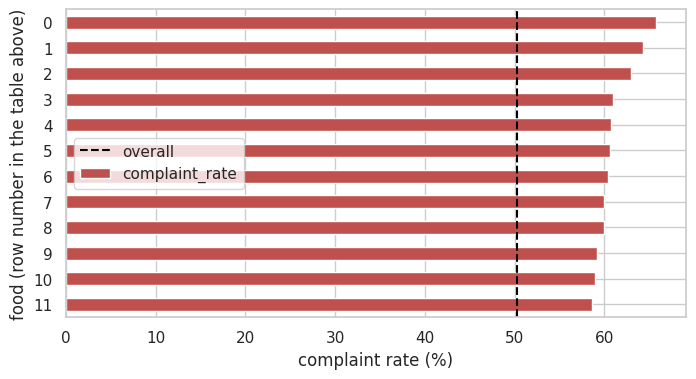

In [15]:
# note: Persian labels are shown in the table above; the chart uses row numbers to avoid broken Persian rendering
ax = foods["complaint_rate"].mul(100).plot(kind="barh", figsize=(8, 4), color="#C0504D")
ax.axvline((full["sentiment"] == 0).mean() * 100, color="black", ls="--", label="overall")
ax.set_yticklabels([f"{i}" for i in foods.index])
ax.invert_yaxis()
ax.set_xlabel("complaint rate (%)")
ax.set_ylabel("food (row number in the table above)")
ax.legend()
plt.show()

## B2. The «دیر» (late) puzzle from notebook 03
The baseline gave «دیر» a weight close to zero. Where does «دیر» show up in **positive** reviews?

In [16]:
has_late = full["clean_text"].str.contains(r"\bدیر\b", regex=True)
print(f"Reviews with «دیر»: {has_late.sum():,}  |  complaint rate: {(full.loc[has_late, 'sentiment'] == 0).mean():.1%}\n")

def context(texts, word, n=15):
    c = Counter()
    for t in texts:
        toks = t.split()
        for i, tok in enumerate(toks):
            if tok == word:
                c[" ".join(toks[max(0, i - 1): i + 2])] += 1
    return pd.Series(dict(c.most_common(n)))

happy_ctx = context(full.loc[has_late & (full["sentiment"] == 1), "clean_text"], "دیر").reset_index()
sad_ctx = context(full.loc[has_late & (full["sentiment"] == 0), "clean_text"], "دیر").reset_index()
happy_ctx.columns = ["in HAPPY reviews", "n (happy)"]
sad_ctx.columns = ["in SAD reviews", "n (sad)"]
pd.concat([happy_ctx, sad_ctx], axis=1)

Reviews with «دیر»: 1,607  |  complaint rate: 58.4%



,in HAPPY reviews,n (happy),in SAD reviews,n (sad)
0,خیلی دیر رسید,94,خیلی دیر رسید,165
1,غذا دیر رسید,25,غذا دیر رسید,44
2,یکم دیر رسید,25,بسیار دیر رسید,34
3,دیر رسید,23,خیلی دیر تحویل,31
4,کمی دیر رسید,20,خیلی دیر دستم,31
5,خیلی دیر دستم,18,خیلی دیر اومد,21
6,خیلی دیر ارسال,13,دیر رسید,20
7,فقط دیر رسید,12,بسیار دیر تحویل,15
8,خیلی دیر دستمون,9,خیلی دیر سرد,15
9,خیلی دیر,9,خیلی دیر ارسال,15


## B3. Clustering the negative reviews
Steps:
1. **TF-IDF** on the negative reviews (words + word pairs)
2. **TruncatedSVD** squeezes ~thousands of features into 100 "topics", which makes clustering faster and less noisy
3. **KMeans** groups reviews with similar words into `k` clusters

How many clusters? We try k = 4...12 and look at two measures:
- **inertia** (elbow method): lower is tighter, look for the "elbow" where it stops dropping fast
- **silhouette score**: higher means clusters are better separated

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer as VecNormalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

neg = full[(full["sentiment"] == 0) & (full["clean_text"].str.split().str.len() >= 3)].reset_index(drop=True)
print(f"Negative reviews used: {len(neg):,}")

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.3, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(neg["clean_text"])
lsa = make_pipeline(TruncatedSVD(n_components=100, random_state=42), VecNormalizer(copy=False))
X = lsa.fit_transform(X_tfidf)
print("TF-IDF features:", X_tfidf.shape[1], "-> reduced to", X.shape[1])

Negative reviews used: 34,506
TF-IDF features: 17535 -> reduced to 100


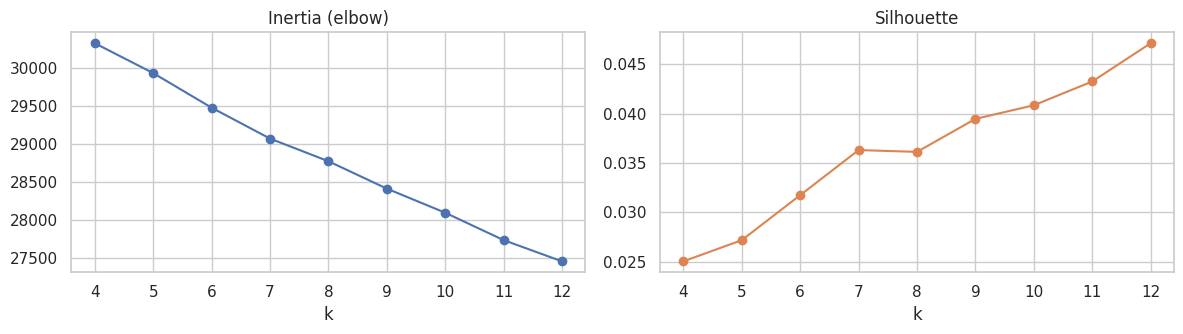

CPU times: user 56.3 s, sys: 482 ms, total: 56.8 s
Wall time: 43.3 s


,k,inertia,silhouette
0,4,30329.6108,0.0251
1,5,29936.5341,0.0272
2,6,29481.4229,0.0318
3,7,29074.6819,0.0363
4,8,28776.5209,0.0361
5,9,28416.1730,0.0395
6,10,28098.9872,0.0408
7,11,27738.4658,0.0433
8,12,27459.0555,0.0471


In [18]:
%%time
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), size=min(5000, len(X)), replace=False)

scan = []
for k in range(4, 13):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    scan.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X[sample_idx], km.labels_[sample_idx])})
scan = pd.DataFrame(scan)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(scan["k"], scan["inertia"], "o-"); axes[0].set_title("Inertia (elbow)"); axes[0].set_xlabel("k")
axes[1].plot(scan["k"], scan["silhouette"], "o-", color="C1"); axes[1].set_title("Silhouette"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()
scan.round(4)

Text clusters are rarely perfectly separated, so silhouette scores are usually low (0.02-0.1). Pick a `k` that is reasonable on the charts **and** gives clusters you can name. Change `K` below and re-run if the clusters look mixed.

In [19]:
K = 8   # <- change after looking at the charts above

km = KMeans(n_clusters=K, n_init=20, random_state=42).fit(X)
neg["cluster"] = km.labels_

# top terms: average TF-IDF of each term inside each cluster
terms = tfidf.get_feature_names_out()
top_terms = {}
for c in range(K):
    mean_tfidf = np.asarray(X_tfidf[neg["cluster"].values == c].mean(axis=0)).ravel()
    top_terms[c] = ", ".join(terms[mean_tfidf.argsort()[::-1][:12]])

summary = pd.DataFrame({
    "size": neg["cluster"].value_counts().sort_index(),
    "share %": (neg["cluster"].value_counts(normalize=True).sort_index() * 100).round(1),
    "top terms": pd.Series(top_terms),
})
summary

,size,share %,top terms
0,9600,27.8,"نبود, اصلا, پیتزا, خوب, مرغ, مزه, نداشت, می, بد, داد, طعم, خوب نبود"
1,3912,11.3,"کیفیت, پایین, بی, بی کیفیت, بسیار, غذا, کیفیت غذا, کیفیت پایین, بسیار پایین, واقعا, خیلی, بد"
2,1786,5.2,"دادم, سفارش دادم, سفارش, دادم ولی, ولی, فرستادن, برام, اما, دادم اما, می, دیگه, واقعا"
3,3542,10.3,"خیلی, خیلی بد, بد, خیلی خیلی, کم, خیلی کم, پیتزا, کیفیت, غذا, مزه, غذا خیلی, ولی"
4,1814,5.3,"سیب, زمینی, سیب زمینی, زمینی ها, خیلی, ها, سرد, غذا, کیفیت, پیتزا, مونده, نبود"
5,7825,22.7,"شیرینی, سفارش, کیک, ها, پیک, شده, بودم, تحویل, ولی, نان, بسته, یه"
6,1706,4.9,"ارسال, ارسال شده, شده, سفارش, ارسال نشده, نشده, اشتباه, ارسال نشد, نشد, اشتباه ارسال, نوشابه, بودم"
7,4321,12.5,"سرد, غذا, رسید, ساعت, غذا سرد, تحویل, کاملا, کاملا سرد, تاخیر, دقیقه, دیر, کشید"


In [20]:
# 3 example reviews from each cluster
for c in range(K):
    print(f"\n=== cluster {c}  ({summary.loc[c, 'size']:,} reviews) ===")
    for t in neg.loc[neg["cluster"] == c, "comment"].sample(3, random_state=1):
        print("  -", t[:170])


=== cluster 0  (9,600 reviews) ===
  - یکی از بدترین ماشروم برگر هایی بود که خوردم
  - نان کاملا بیات سینه مرغ سفت واقعا راضی نبودم
  - بسیار بد بود بسیار بد مزه بود بسیار بد واقعا اگه مهم هستش براتون رسیدگی کنید

=== cluster 1  (3,912 reviews) ===
  - مهمترین عامل رونق کسب و کار شما جلب اعتماد مشتری با ارائه اجناس باکیفیت در قبال هزینه دریافتی ست. از این خرید بی اعتمادی نسبت به شما نصیب من شد. میوه‌های بسیار بی کیفیت..
  - کیفیت واقعا افت فاحشی داره حیف اون همه خاطره ما از پیتزا پرپروک
  - بی نهایت بی کیفیت و کم حجم از خیارشور و گوجه هم مضایغه کردند چه برسه به گوشت داخل کباب ترکی

=== cluster 2  (1,786 reviews) ===
  - من پیتزا مارگاریتا سفارش دادم ولی اصلا اون پیتزا هیچ شباهتی به مارگاریتا نداشت لطفا رسپی درست رو اجرا کنید یه پیتزا من دراوردی به اسم مارگاریتا برای من فرستادین
  - من آش شله قلمکار سفارش دادم رشته فرستادین! نمیتونین مدیریت کنین سفارش نگیرید!
  - سلام من کیک کاراملی سفارش دادم ولی برام وانیلی آوردن نمیدونم چی بگم والا واقعا متاسف هستم براتون.

=== cluster 3  (3,542 rev

## B4. Name the clusters
Read the top terms and examples above, then give each cluster a short **English** name (English so the chart renders correctly).
Example names: *Cold food*, *Late delivery*, *Small portion / price*, *Wrong or missing items*, *Taste / quality*, *Bad courier*.

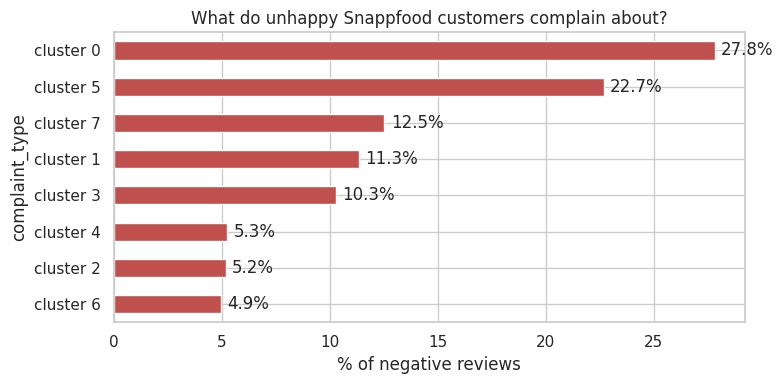

In [21]:
CLUSTER_NAMES = {
    0: "cluster 0",
    1: "cluster 1",
    2: "cluster 2",
    3: "cluster 3",
    4: "cluster 4",
    5: "cluster 5",
    6: "cluster 6",
    7: "cluster 7",
}   # <- replace with your names; add or remove lines if you changed K

neg["complaint_type"] = neg["cluster"].map(CLUSTER_NAMES)
shares = neg["complaint_type"].value_counts(normalize=True).mul(100).sort_values()

ax = shares.plot(kind="barh", figsize=(8, 4), color="#C0504D")
ax.set_xlabel("% of negative reviews")
ax.set_title("What do unhappy Snappfood customers complain about?")
for i, v in enumerate(shares):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

## B5. Unusual complaints (outlier detection)
Reviews that are **far from every cluster center** don't fit any common complaint type.
They are often rare but important issues (e.g. food safety), or noise.

In [22]:
dist_to_center = km.transform(X).min(axis=1)
neg["distance"] = dist_to_center
threshold = np.percentile(dist_to_center, 99)
print(f"Top 1% most unusual reviews (distance > {threshold:.3f}): {(dist_to_center > threshold).sum()}")

neg.sort_values("distance", ascending=False)[["comment", "distance"]].head(15)

Top 1% most unusual reviews (distance > 1.013): 346


,comment,distance
23432,"One time again fork and knife is missing in slad, we have complained multiple times on this case but still no feedback- Writing the issue ine time again Sometimes th resturant sends fork and knife...",1.037289
1484,"I am very grateful with your service and always considering Royal Address as the first option- However, today I missed two cans coca-cola- Can you please find out what happened? thank you very muc...",1.037021
16438,"This is ۵th time they have sent the salad with fork and knife, i hope snappfood talks to resturant one time and cleara it up, as its v annoying",1.036876
9558,No spoon and fork,1.036874
16205,No fork and spoon-,1.036874
30430,Wrong order and he refused to replace it,1.036768
34191,The pizza was delivered late AND cold- The fries were soggy- The delivery charges are way too much- ۶۵۰۰ thomans for deluvery in the same area is insane- And that too for a cold pizza and soggy fries,1.036556
603,They didn't read the comments I added at all then sent different things when i called they where so ruded it is my last time i order from here,1.036510
3873,Despite selecting fork and knife none was sent,1.036507
29288,Margarita pizza is the simplest pizza and a great test for a pizza place- The Italians don’t bake the pizza with basil for a reason,1.036430


## B6. Save for the dashboard (notebook 06)

In [23]:
neg[["comment", "cluster", "complaint_type", "distance"]].to_csv(f"{BASE_DIR}/complaints_clustered.csv", index=False)
foods.to_csv(f"{BASE_DIR}/food_complaint_rates.csv", index=False)
print("Saved complaints_clustered.csv and food_complaint_rates.csv to", BASE_DIR)

Saved complaints_clustered.csv and food_complaint_rates.csv to /content/drive/MyDrive/snappfood-sentiment


## Key findings
*(fill in after running)*
-
-
-